# GATEWay DARS vs. Online Rating Baselines on ASSISTments 2012-2013

This Jupyter Notebook presents a comprehensive, rigorous benchmark evaluating the **GATEWay Dynamic Adaptive Rating System (DARS)** and its calibrated variant (**DARS+**) against standard online student skill tracking baselines—**Fixed Elo** and **Glicko-2**—on the large-scale **ASSISTments 2012-2013 Dataset**.

---

## 1. Mathematical Formulation & Mappings
The ASSISTments dataset consists of **6,044,359 valid student attempts** across **46,674 unique learners**. We map the features to the DARS mathematical models:
- **Expected success probability ($E$):** standard Elo prediction based on student skill $R_i$ and item difficulty $R_j$:
  $$E = \frac{1}{1 + 10^{(R_j - R_i)/400}}$$
- **Continuous Performance Quality ($P(q)$):**
  - If correct ($S = 1$): $P(q) = w_\tau \tau(q) + w_h (1 - H(q))$
    - $\tau(q) = e^{-\text{overlap\_time} / 30000}$ (response time efficiency).
    - $H(q) = \min(1.0, \text{hint\_count} / 5.0)$ (hint penalty).
    - $w_\tau = 0.8$, $w_h = 0.2$.
  - If incorrect ($S = 0$): $P(q) = 0.0$.
- **Streak Multiplier ($\phi(k)$):**
  - Bounded streak multiplier of $1.2$ for correct/incorrect streaks $\ge 3$ correct/incorrect attempts.
- **Dynamic uncertainty-decaying K-factor:**
  - $K$ factor decays with practice count: $K_s = \max(8.0, 32.0 / (1.0 + 0.01 \times n_i))$.

---

## 2. Baseline Models
1. **Static Start Baseline:** A constant prediction (the global mean correctness of the training set).
2. **Fixed Elo ($K=32$):** Standard online joint Elo update for student skill and item difficulties.
3. **Glicko-2:** Dynamic student tracking incorporating rating deviation (uncertainty) per attempt.
4. **DARS (Uncalibrated):** Raw expected correctness computed from DARS temporal student ratings.
5. **DARS+ Calibrated:** A Logistic Regression model trained on a 70% student split using pre-answer features (`dars_logit`, `streak_before`, `time_efficiency`, `hint_penalty`, and `rating_gap`), evaluated on 30% held-out students.


In [1]:
import pandas as pd
import numpy as np
import math
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, accuracy_score
from sklearn.calibration import calibration_curve

# Matplotlib styling for premium look
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


In [2]:
start_time = time.time()
csv_path = r'C:\Users\sunil\Downloads\btech-project\2012-2013-data-with-predictions-4-final.csv'

print("Loading essential columns of the 3GB dataset...")
cols = ['user_id', 'problem_id', 'correct', 'overlap_time', 'start_time', 'hint_count', 'attempt_count', 'assignment_id']
df = pd.read_csv(csv_path, usecols=cols)
print(f"Loaded {len(df):,} rows in {time.time() - start_time:.2f} seconds.")

print("Cleaning and sorting data chronologically...")
df = df[df['correct'].isin([0, 1])].copy()
df['correct'] = df['correct'].astype(int)
df['overlap_time'] = pd.to_numeric(df['overlap_time'], errors='coerce').fillna(22000.0)
df['hint_count'] = pd.to_numeric(df['hint_count'], errors='coerce').fillna(0).astype(int)
df['attempt_count'] = pd.to_numeric(df['attempt_count'], errors='coerce').fillna(1).astype(int)
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df = df.dropna(subset=['start_time', 'user_id', 'problem_id']).copy()

# Sort chronologically to preserve temporal validity and prevent leaks
df = df.sort_values('start_time').reset_index(drop=True)
print(f"Filtered to {len(df):,} valid attempts.")


Loading essential columns of the 3GB dataset...
Loaded 6,123,270 rows in 15.54 seconds.
Cleaning and sorting data chronologically...
Filtered to 6,044,359 valid attempts.


## 2. Exploratory Data Analysis (EDA) and Feature Insights

Before replaying the online rating simulations, let's explore the raw features of the ASSISTments dataset. This will help us understand the distribution of student learning behaviors and validate the design choices of the DARS formulation.


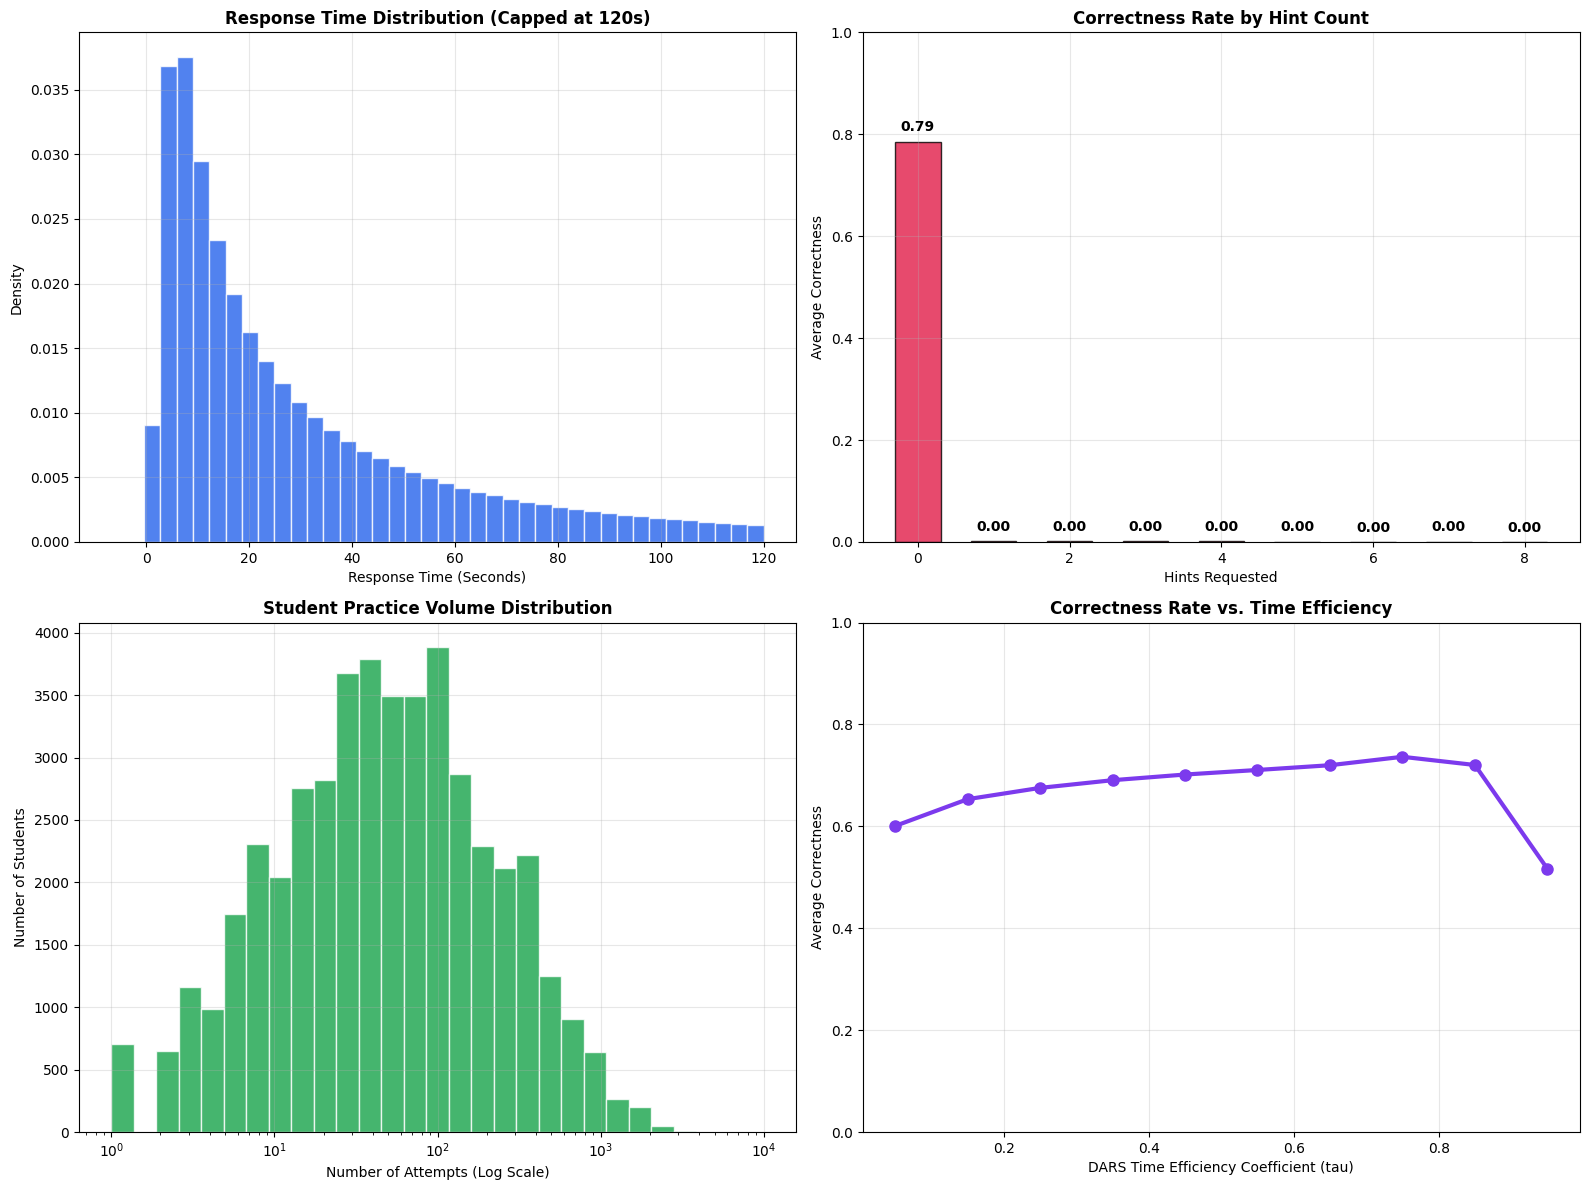

In [3]:
# EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATIONS
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Response Time Distribution
sec = df['overlap_time'] / 1000.0
axes[0, 0].hist(sec[sec <= 120], bins=40, color='#2563EB', edgecolor='white', alpha=0.8, density=True)
axes[0, 0].set_title('Response Time Distribution (Capped at 120s)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Response Time (Seconds)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].grid(alpha=0.3)

# 2. Correctness Rate by Hint Count
hint_stats = df.groupby('hint_count')['correct'].agg(['mean', 'count'])
hint_stats = hint_stats[hint_stats['count'] > 1000] # representative counts
axes[0, 1].bar(hint_stats.index, hint_stats['mean'], color='#E11D48', edgecolor='black', alpha=0.8, width=0.6)
axes[0, 1].set_title('Correctness Rate by Hint Count', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hints Requested')
axes[0, 1].set_ylabel('Average Correctness')
axes[0, 1].set_ylim(0.0, 1.0)
axes[0, 1].grid(alpha=0.3)
for idx, val in zip(hint_stats.index, hint_stats['mean']):
    axes[0, 1].text(idx, val + 0.02, f"{val:.2f}", ha='center', fontsize=10, fontweight='semibold')

# 3. Student Activity Level (Log Scale)
attempts_per_student = df.groupby('user_id').size()
axes[1, 0].hist(attempts_per_student, bins=np.logspace(0, 4, 30), color='#16A34A', edgecolor='white', alpha=0.8)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Student Practice Volume Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Attempts (Log Scale)')
axes[1, 0].set_ylabel('Number of Students')
axes[1, 0].grid(alpha=0.3)

# 4. Correctness by Time Efficiency Bin
# DARS time efficiency formulation: tau = exp(-response_time_seconds / 30)
df['time_efficiency'] = np.exp(- (df['overlap_time'] / 1000.0) / 30.0)
df['eff_bin'] = pd.cut(df['time_efficiency'], bins=np.linspace(0, 1, 11))
eff_stats = df.groupby('eff_bin', observed=False)['correct'].mean()
bin_centers = np.linspace(0.05, 0.95, 10)
axes[1, 1].plot(bin_centers, eff_stats.values, marker='o', color='#7C3AED', linewidth=3, markersize=8)
axes[1, 1].set_title('Correctness Rate vs. Time Efficiency', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('DARS Time Efficiency Coefficient (tau)')
axes[1, 1].set_ylabel('Average Correctness')
axes[1, 1].set_ylim(0.0, 1.0)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Question Knowledge Graph from ASSISTments

The graph below treats each `problem_id` as a question node. Edges combine two signals: questions connected by the same skill tag, and questions that appear consecutively in a learner sequence. The visualization intentionally uses a bounded high-support subgraph so the notebook remains readable and does not attempt to draw every question in the dataset.


Loading minimal columns for question graph construction...
Question graph built in 21.38s: 144 question nodes, 362 edges.


C:\Users\sunil\AppData\Local\Temp\ipykernel_40884\3399923748.py:92: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(1, len(skills)))


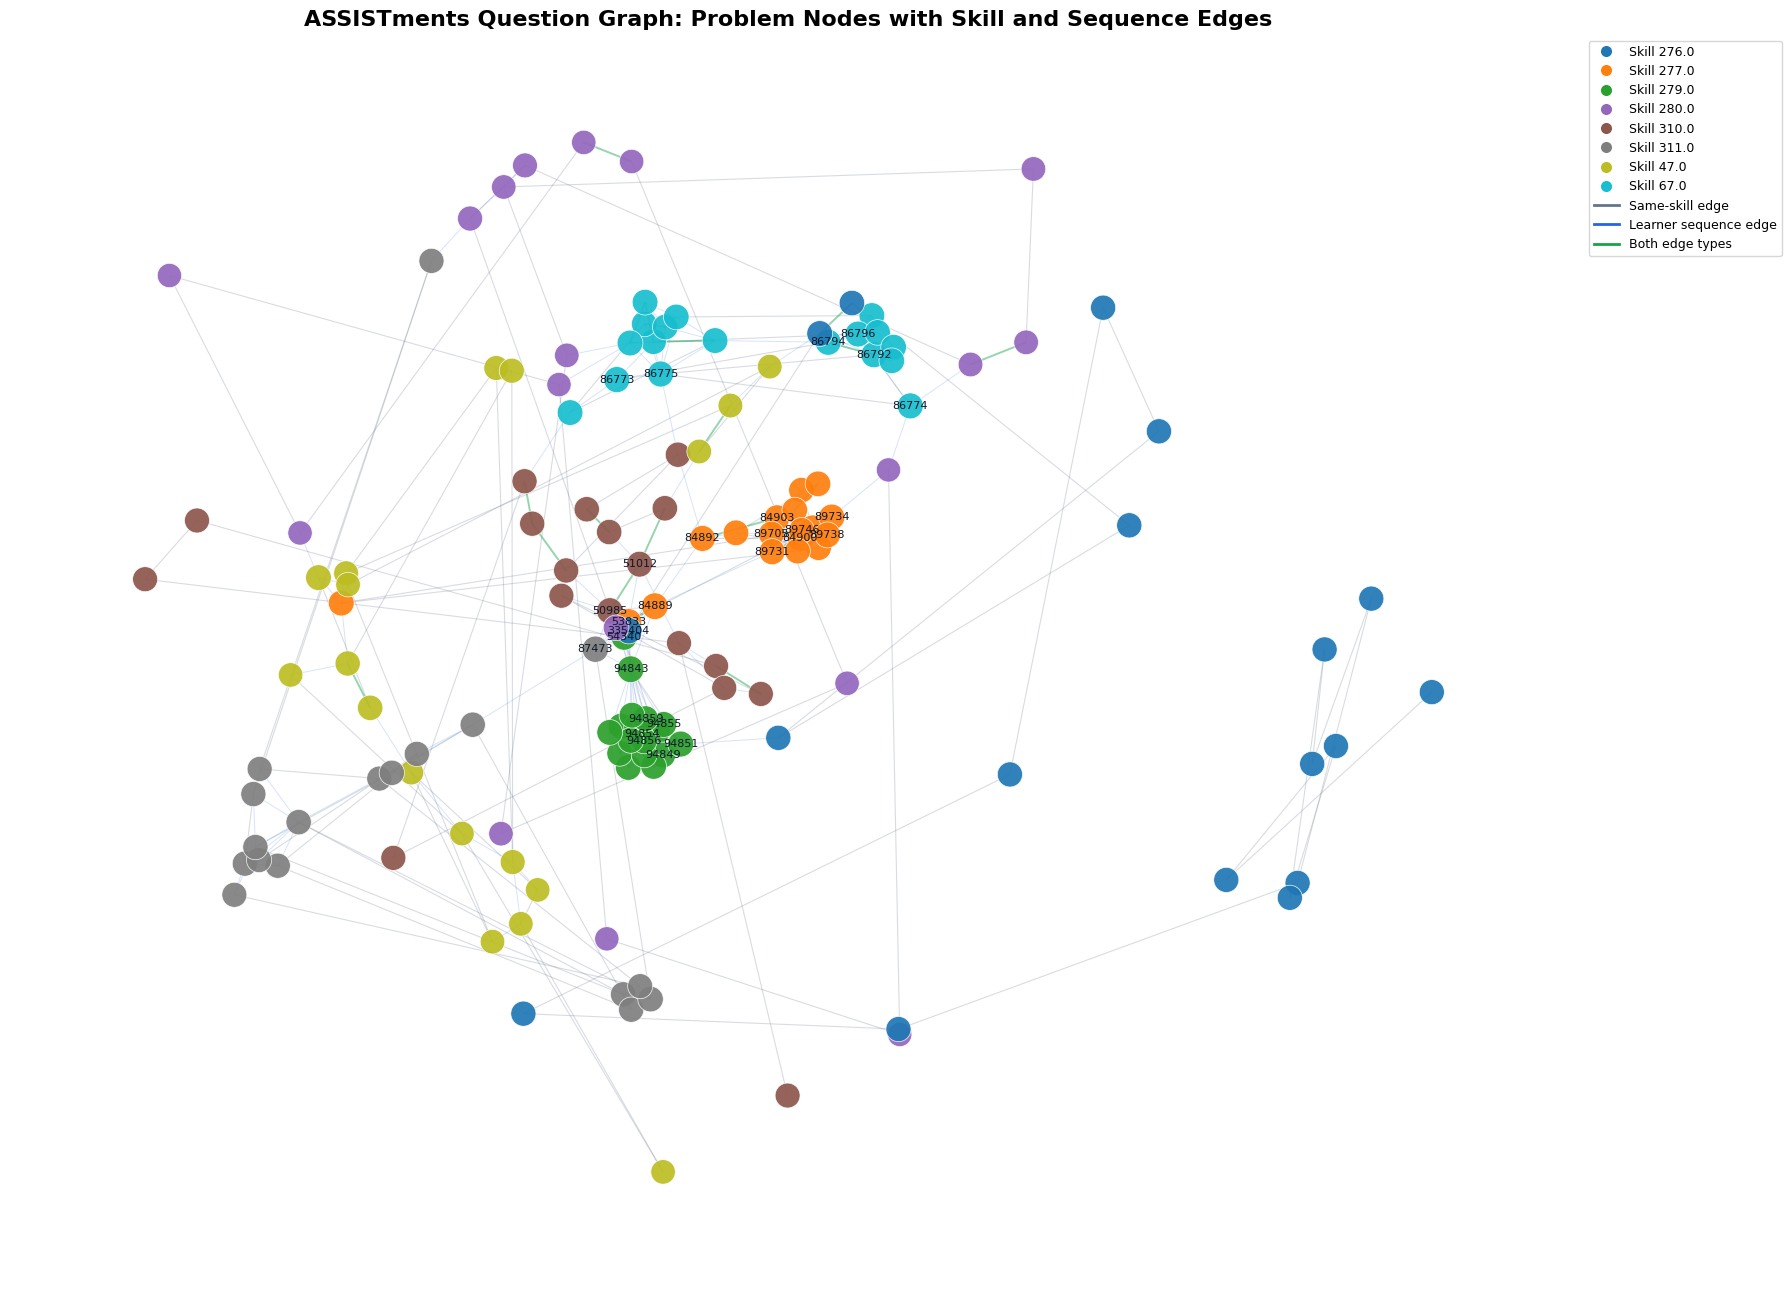

Saved graph plot to paper_figures/assistments_question_graph.png


In [4]:
# QUESTION GRAPH VISUALIZATION: nodes are ASSISTments questions (problem_id)
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

graph_start = time.time()
graph_cols = ['user_id', 'problem_id', 'skill_id', 'skill', 'start_time', 'correct']
print("Loading minimal columns for question graph construction...")
graph_df = pd.read_csv(csv_path, usecols=lambda c: c in graph_cols)

graph_df = graph_df.dropna(subset=['user_id', 'problem_id', 'start_time']).copy()
graph_df['start_time'] = pd.to_datetime(graph_df['start_time'], errors='coerce')
graph_df = graph_df.dropna(subset=['start_time']).copy()
graph_df['correct'] = pd.to_numeric(graph_df['correct'], errors='coerce')

# Use skill_id when present; fall back to skill text for rows without skill_id.
graph_df['skill_key'] = graph_df['skill_id'].astype('string')
if 'skill' in graph_df.columns:
    graph_df['skill_key'] = graph_df['skill_key'].fillna(graph_df['skill'].astype('string'))
graph_df = graph_df.dropna(subset=['skill_key']).copy()

# Bound the plotted graph to the most frequent skills and most attempted questions.
MAX_SKILLS = 8
MAX_QUESTIONS_PER_SKILL = 18
MAX_SEQUENCE_EDGES = 260

top_skills = graph_df['skill_key'].value_counts().head(MAX_SKILLS).index.tolist()
skill_slice = graph_df[graph_df['skill_key'].isin(top_skills)].copy()

question_stats = (
    skill_slice.groupby(['skill_key', 'problem_id'])
    .agg(attempts=('correct', 'size'), accuracy=('correct', 'mean'))
    .reset_index()
)

selected_questions = set()
for skill_key, part in question_stats.groupby('skill_key'):
    keep = part.sort_values('attempts', ascending=False).head(MAX_QUESTIONS_PER_SKILL)
    selected_questions.update(keep['problem_id'].tolist())

plot_df = skill_slice[skill_slice['problem_id'].isin(selected_questions)].copy()
plot_stats = (
    plot_df.groupby('problem_id')
    .agg(
        attempts=('correct', 'size'),
        accuracy=('correct', 'mean'),
        skill_key=('skill_key', lambda x: x.mode().iloc[0] if not x.mode().empty else str(x.iloc[0]))
    )
    .reset_index()
)

G = nx.Graph()
for row in plot_stats.itertuples(index=False):
    G.add_node(
        str(row.problem_id),
        skill=str(row.skill_key),
        attempts=int(row.attempts),
        accuracy=float(row.accuracy) if pd.notna(row.accuracy) else np.nan,
    )

# Same-skill edges: connect high-support questions inside each skill as a chain.
for skill_key, part in plot_stats.groupby('skill_key'):
    ordered = part.sort_values('attempts', ascending=False)['problem_id'].astype(str).tolist()
    for left, right in zip(ordered, ordered[1:]):
        G.add_edge(left, right, edge_type='same_skill', weight=1.0)

# Sequential edges: connect questions that occur consecutively for the same learner.
seq_df = plot_df.sort_values(['user_id', 'start_time'])[['user_id', 'problem_id']]
edge_counts = {}
for _, user_part in seq_df.groupby('user_id', sort=False):
    problems = user_part['problem_id'].astype(str).tolist()
    for left, right in zip(problems, problems[1:]):
        if left == right:
            continue
        edge = tuple(sorted((left, right)))
        edge_counts[edge] = edge_counts.get(edge, 0) + 1

for (left, right), count in sorted(edge_counts.items(), key=lambda item: item[1], reverse=True)[:MAX_SEQUENCE_EDGES]:
    if G.has_edge(left, right):
        G[left][right]['edge_type'] = 'same_skill+sequence'
        G[left][right]['weight'] += count
    else:
        G.add_edge(left, right, edge_type='sequence', weight=count)

print(f"Question graph built in {time.time() - graph_start:.2f}s: {G.number_of_nodes():,} question nodes, {G.number_of_edges():,} edges.")

# Plot the bounded question graph.
plt.figure(figsize=(18, 13))
pos = nx.spring_layout(G, seed=42, k=0.55, weight='weight', iterations=80)

skills = sorted({data['skill'] for _, data in G.nodes(data=True)})
cmap = plt.cm.get_cmap('tab10', max(1, len(skills)))
skill_color = {skill: cmap(i % 10) for i, skill in enumerate(skills)}
node_colors = [skill_color[G.nodes[node]['skill']] for node in G.nodes()]
node_sizes = [90 + 38 * np.log1p(G.nodes[node]['attempts']) for node in G.nodes()]

same_skill_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'same_skill']
sequence_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'sequence']
mixed_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'same_skill+sequence']

nx.draw_networkx_edges(G, pos, edgelist=same_skill_edges, width=0.8, alpha=0.25, edge_color='#64748B')
nx.draw_networkx_edges(G, pos, edgelist=sequence_edges, width=0.7, alpha=0.18, edge_color='#2563EB')
nx.draw_networkx_edges(G, pos, edgelist=mixed_edges, width=1.4, alpha=0.45, edge_color='#16A34A')
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, linewidths=0.5, edgecolors='white', alpha=0.92)

# Label only the most attempted questions to keep the plot readable.
top_label_nodes = sorted(G.nodes(), key=lambda n: G.nodes[n]['attempts'], reverse=True)[:28]
labels = {node: node for node in top_label_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color='#0F172A')

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=f"Skill {skill}", markerfacecolor=skill_color[skill], markersize=9)
    for skill in skills[:10]
]
edge_handles = [
    Line2D([0], [0], color='#64748B', lw=2, label='Same-skill edge'),
    Line2D([0], [0], color='#2563EB', lw=2, label='Learner sequence edge'),
    Line2D([0], [0], color='#16A34A', lw=2, label='Both edge types'),
]
plt.legend(handles=legend_handles + edge_handles, loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True, fontsize=9)
plt.title('ASSISTments Question Graph: Problem Nodes with Skill and Sequence Edges', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()

output_path = 'paper_figures/assistments_question_graph.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()
print(f"Saved graph plot to {output_path}")


In [5]:
# 70% student training split / 30% held-out test split
unique_users = df['user_id'].unique()
np.random.seed(2026)
np.random.shuffle(unique_users)
train_user_count = int(0.70 * len(unique_users))
train_users = set(unique_users[:train_user_count])

df['split'] = np.where(df['user_id'].isin(train_users), 'train', 'test')
print(f"Training students: {train_user_count:,}, Testing students: {len(unique_users) - train_user_count:,}")


Training students: 32,443, Testing students: 13,905


In [6]:
# Mathematical helpers
def elo_expected(student_rating, problem_difficulty):
    return 1.0 / (1.0 + 10.0 ** ((problem_difficulty - student_rating) / 400.0))

def clip_prob(p):
    return np.clip(p, 1e-6, 1.0 - 1e-6)

# ECE Calculation Helper (10 bins)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower = bin_edges[i]
        bin_upper = bin_edges[i+1]
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if i == n_bins - 1:
            in_bin = in_bin | (y_prob == bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

# Glicko-2 G function
def glicko2_g(phi):
    return 1.0 / math.sqrt(1.0 + 3.0 * (phi ** 2) / (math.pi ** 2))

# Glicko-2 Expectation
def glicko2_expected(mu, opp_mu, opp_phi):
    return 1.0 / (1.0 + math.exp(-glicko2_g(opp_phi) * (mu - opp_mu)))


In [7]:
print("Running Joint Online Rating Simulation over 6.04 Million Rows...")
loop_start = time.time()
elo_students = {}
elo_problems = {}
dars_students = {}
dars_problems = {}
student_streaks = {}
student_attempts = {}
glicko_mu = {}
glicko_phi = {}

elo_probs = np.zeros(len(df))
glicko_probs = np.zeros(len(df))
dars_probs = np.zeros(len(df))
rating_gaps = np.zeros(len(df))
streak_befores = np.zeros(len(df))
time_efficiencies = np.zeros(len(df))
hint_penalties = np.zeros(len(df))

for idx, row in enumerate(df.itertuples()):
    uid = row.user_id
    pid = row.problem_id
    s = row.correct
    overlap = row.overlap_time
    hints = row.hint_count
    
    # 1. Elo
    r_s = elo_students.get(uid, 1500.0)
    d_p = elo_problems.get(pid, 1500.0)
    e_elo = elo_expected(r_s, d_p)
    elo_probs[idx] = e_elo
    elo_students[uid] = r_s + 32.0 * (s - e_elo)
    elo_problems[pid] = d_p - 8.0 * (s - e_elo)
    
    # 2. Glicko-2
    mu_s = glicko_mu.get(uid, 0.0)
    phi_s = glicko_phi.get(uid, 2.0148)
    mu_p = glicko_mu.get(pid, 0.0)
    phi_p = 0.4605
    e_glicko = glicko2_expected(mu_s, mu_p, phi_p)
    glicko_probs[idx] = e_glicko
    g_phi = glicko2_g(phi_p)
    variance_inv = (g_phi ** 2) * e_glicko * (1 - e_glicko)
    if variance_inv > 0:
        d_mu = (phi_s ** 2) / (1.0 + (phi_s ** 2) * variance_inv) * g_phi * (s - e_glicko)
        glicko_mu[uid] = mu_s + d_mu
        phi_s_new = math.sqrt(phi_s ** 2 + 0.001)
        glicko_phi[uid] = max(0.2, min(2.0148, phi_s_new - 0.05))
        
    # 3. DARS
    r_dars = dars_students.get(uid, 1500.0)
    d_dars = dars_problems.get(pid, 1500.0)
    streak = student_streaks.get(uid, 0)
    attempts = student_attempts.get(uid, 0)
    
    e_dars = elo_expected(r_dars, d_dars)
    dars_probs[idx] = e_dars
    
    tau = math.exp(-overlap / 30000.0)
    h_pen = min(1.0, hints / 5.0)
    p_q = 0.8 * tau + 0.2 * (1.0 - h_pen) if s == 1 else 0.0
    phi_k = 1.2 if abs(streak) >= 3 else 1.0
    k_s = max(8.0, 32.0 / (1.0 + 0.01 * attempts))
    
    dars_students[uid] = r_dars + k_s * phi_k * (p_q - e_dars)
    dars_problems[pid] = d_dars - 8.0 * (s - e_dars)
    
    rating_gaps[idx] = r_dars - d_dars
    streak_befores[idx] = streak
    time_efficiencies[idx] = tau
    hint_penalties[idx] = h_pen
    
    student_attempts[uid] = attempts + 1
    if s == 1:
        student_streaks[uid] = streak + 1 if streak >= 0 else 1
    else:
        student_streaks[uid] = streak - 1 if streak <= 0 else -1

print(f"Replay completed in {time.time() - loop_start:.2f} seconds.")


Running Joint Online Rating Simulation over 6.04 Million Rows...
Replay completed in 47.35 seconds.


In [8]:
print("Training DARS+ calibrated model...")
df['elo_prob'] = elo_probs
df['glicko_prob'] = glicko_probs
df['dars_prob'] = dars_probs
df['rating_gap'] = rating_gaps
df['streak_before'] = streak_befores
df['time_efficiency'] = time_efficiencies
df['hint_penalty'] = hint_penalties

train_mask = df['split'] == 'train'
test_mask = df['split'] == 'test'

features_plus = ['dars_logit', 'rating_gap', 'streak_before', 'time_efficiency', 'hint_penalty']

# Construct logit feature
df['dars_logit'] = np.log(clip_prob(df['dars_prob']) / (1.0 - clip_prob(df['dars_prob'])))

X_train = df.loc[train_mask, features_plus]
X_test = df.loc[test_mask, features_plus]
y_train = df.loc[train_mask, 'correct'].values
y_test = df.loc[test_mask, 'correct'].values

clf = LogisticRegression(max_iter=1000, random_state=2026)
clf.fit(X_train, y_train)

df.loc[test_mask, 'dars_plus_prob'] = clf.predict_proba(X_test)[:, 1]
df.loc[test_mask, 'static_prob'] = y_train.mean()

print("DARS+ model coefficients:")
for feat, coef in zip(features_plus, clf.coef_[0]):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercept: {clf.intercept_[0]:.4f}")


Training DARS+ calibrated model...
DARS+ model coefficients:
  dars_logit: 0.0000
  rating_gap: 0.0028
  streak_before: 0.0739
  time_efficiency: -0.0036
  hint_penalty: -30.7692
  Intercept: 1.2358


In [9]:
# EVALUATING ALL MODELS ON HELD-OUT TEST STUDENTS
test_df = df[df['split'] == 'test'].copy()
y_true = test_df['correct'].values

models = {
    'Static Start': 'static_prob',
    'Fixed Elo K=32': 'elo_prob',
    'Glicko-2': 'glicko_prob',
    'DARS': 'dars_prob',
    'DARS+ Calibrated': 'dars_plus_prob'
}

results = []
for name, col in models.items():
    p = test_df[col].values
    results.append({
        'Model': name,
        'Brier Score': brier_score_loss(y_true, p),
        'Log Loss': log_loss(y_true, clip_prob(p)),
        'Accuracy': accuracy_score(y_true, p >= 0.5),
        'ROC AUC': roc_auc_score(y_true, p),
        'ECE (10 bins)': expected_calibration_error(y_true, p)
    })

results_df = pd.DataFrame(results).sort_values('Brier Score')
display(results_df.round(4))


,Model,Brier Score,Log Loss,Accuracy,ROC AUC,ECE (10 bins)
4,DARS+ Calibrated,0.1368,0.4251,0.8141,0.8131,0.0096
1,Fixed Elo K=32,0.1812,0.5407,0.7341,0.7475,0.0244
2,Glicko-2,0.2077,0.6090,0.6885,0.6630,0.0491
0,Static Start,0.2198,0.6314,0.6739,0.5000,0.0049
3,DARS,0.2562,0.7125,0.5534,0.6705,0.2226


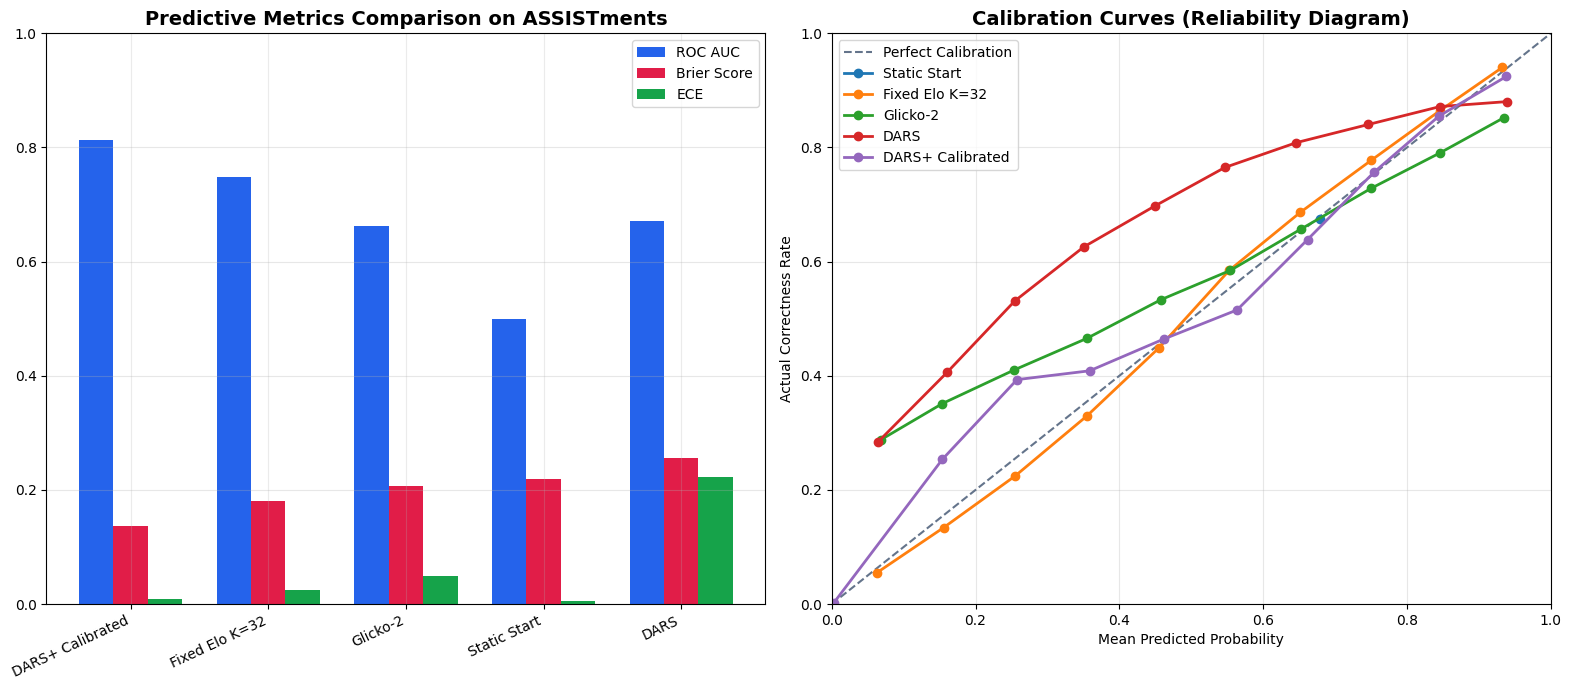

In [10]:
# PLOT METRIC COMPARISON AND CALIBRATION CURVES
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Bar Chart of Model Metrics
model_names = results_df['Model'].values
auc_scores = results_df['ROC AUC'].values
brier_scores = results_df['Brier Score'].values
ece_scores = results_df['ECE (10 bins)'].values

x = np.arange(len(model_names))
width = 0.25

axes[0].bar(x - width, auc_scores, width, label='ROC AUC', color='#2563EB')
axes[0].bar(x, brier_scores, width, label='Brier Score', color='#E11D48')
axes[0].bar(x + width, ece_scores, width, label='ECE', color='#16A34A')

axes[0].set_title('Predictive Metrics Comparison on ASSISTments', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=25, ha='right')
axes[0].set_ylim(0.0, 1.0)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 2. Calibration Curve
axes[1].plot([0, 1], [0, 1], linestyle='--', color='#64748B', label='Perfect Calibration')

for name, col in models.items():
    p = test_df[col].values
    prob_true, prob_pred = calibration_curve(y_true, p, n_bins=10)
    axes[1].plot(prob_pred, prob_true, marker='o', label=name, linewidth=2)

axes[1].set_title('Calibration Curves (Reliability Diagram)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Actual Correctness Rate')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
